In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


e:\GitHub\dpp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "sshikamaru/car-object-detection"
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\car-object-detection' already exists with files. Skipping download (replace=False).


In [3]:
dataset_name

'car-object-detection'

In [25]:
files

['data']

In [26]:
import os

files = os.listdir("../data/raw/car-object-detection/data")

files

['data.yaml',
 'images',
 'labels',
 'runs',
 'sample_submission.csv',
 'testing_images',
 'training_images',
 'train_solution_bounding_boxes (1).csv']

In [27]:
df = pd.read_csv("/".join(["../data/raw", dataset_name, 'data', files[-1]]))
df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [28]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(559, 5)

'Description'

,count,mean,std,min,25%,50%,75%,max
xmin,559.0,263.39,207.37,0.00,61.39,236.75,446.84,645.18
ymin,559.0,186.52,9.32,148.40,180.11,187.52,193.88,208.06
xmax,559.0,365.32,213.50,28.56,166.31,348.59,571.32,676.00
ymax,559.0,231.50,13.99,198.32,223.23,230.56,237.90,308.32


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
image,object,0,355,"[vid_4_9600.jpg, vid_4_17560.jpg, vid_4_6360.jpg]"
xmin,float64,0,440,"[239.1924747, 614.8567294, 82.71522214]"
ymin,float64,0,149,"[188.9913127, 196.3528174, 196.8162806]"
xmax,float64,0,438,"[68.96960926, 118.3733719, 56.12818645]"
ymax,float64,0,184,"[217.8458816, 228.839864, 237.4083012]"


In [29]:
df.groupby('image').size().loc[lambda x: x > 1].sort_values(ascending=False)

image
vid_4_26460.jpg    7
vid_4_6240.jpg     6
vid_4_2000.jpg     5
vid_4_26380.jpg    5
vid_4_26420.jpg    5
                  ..
vid_4_9580.jpg     2
vid_4_9600.jpg     2
vid_4_9640.jpg     2
vid_4_9780.jpg     2
vid_4_9800.jpg     2
Length: 119, dtype: int64

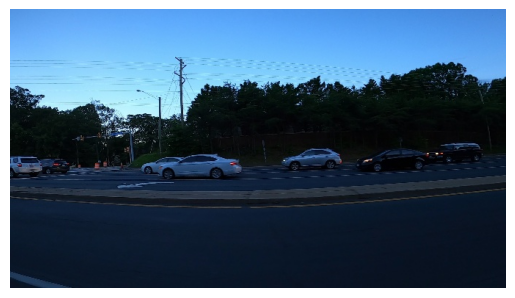

In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_image_path = os.path.join("..", "data", "raw", dataset_name, "data", "training_images")

img = mpimg.imread(os.path.join(train_image_path, "vid_4_26460.jpg"))

plt.imshow(img)
plt.axis('off')
plt.show()

In [31]:
from PIL import Image

with Image.open(os.path.join(train_image_path, "vid_4_26460.jpg")) as img:
    print(img.size)

(676, 380)


In [32]:
for img_name in df.loc[:,'image'].unique():
    with Image.open(os.path.join(train_image_path, img_name)) as img:
        df.loc[df['image'] == img_name, 'image_width'] = img.size[0]
        df.loc[df['image'] == img_name, 'image_height'] = img.size[1]

df.head()

,image,xmin,ymin,xmax,ymax,image_width,image_height
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547,676.0,380.0
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180,676.0,380.0
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180,676.0,380.0
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575,676.0,380.0
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422,676.0,380.0


In [33]:
for idx in df.index:
    df.loc[idx,'x_center'] = (df.loc[idx, 'xmin'] + df.loc[idx, 'xmax']) / 2 / df.loc[idx, 'image_width']
    df.loc[idx,'y_center'] = (df.loc[idx, 'ymin'] + df.loc[idx, 'ymax']) / 2 / df.loc[idx, 'image_height']
    df.loc[idx,'width'] = (df.loc[idx, 'xmax'] - df.loc[idx, 'xmin']) / df.loc[idx, 'image_width']
    df.loc[idx,'height'] = (df.loc[idx, 'ymax'] - df.loc[idx, 'ymin']) / df.loc[idx, 'image_height']

df.head()

,image,xmin,ymin,xmax,ymax,image_width,image_height,x_center,y_center,width,height
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547,676.0,380.0,0.450434,0.539817,0.068741,0.095238
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180,676.0,380.0,0.100217,0.557191,0.155572,0.129987
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180,676.0,380.0,0.444645,0.543678,0.181621,0.157014
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575,676.0,380.0,0.833213,0.531451,0.197540,0.155727
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422,676.0,380.0,0.110347,0.559122,0.171491,0.136422


In [34]:
from sklearn.model_selection import train_test_split

img_all = os.listdir(f'../data/raw/{dataset_name}/data/training_images')

img_train, img_val = train_test_split(img_all,
                                      test_size=0.15,
                                      random_state=42)

print(img_train)
print('\n',img_val)

['vid_4_13640.jpg', 'vid_4_3400.jpg', 'vid_4_1980.jpg', 'vid_4_880.jpg', 'vid_4_20560.jpg', 'vid_4_1740.jpg', 'vid_4_29920.jpg', 'vid_4_11100.jpg', 'vid_4_3280.jpg', 'vid_4_2320.jpg', 'vid_4_26240.jpg', 'vid_4_25960.jpg', 'vid_4_26720.jpg', 'vid_4_23140.jpg', 'vid_4_26340.jpg', 'vid_4_17180.jpg', 'vid_4_5720.jpg', 'vid_4_17480.jpg', 'vid_4_17400.jpg', 'vid_4_1840.jpg', 'vid_4_21020.jpg', 'vid_4_12320.jpg', 'vid_4_980.jpg', 'vid_4_21160.jpg', 'vid_4_18420.jpg', 'vid_4_16240.jpg', 'vid_4_1640.jpg', 'vid_4_22860.jpg', 'vid_4_26520.jpg', 'vid_4_21300.jpg', 'vid_4_2440.jpg', 'vid_4_18840.jpg', 'vid_4_21920.jpg', 'vid_4_29400.jpg', 'vid_4_12860.jpg', 'vid_4_18280.jpg', 'vid_4_1860.jpg', 'vid_4_7760.jpg', 'vid_4_29940.jpg', 'vid_4_9040.jpg', 'vid_4_3960.jpg', 'vid_4_22900.jpg', 'vid_4_14500.jpg', 'vid_4_14780.jpg', 'vid_4_19400.jpg', 'vid_4_17800.jpg', 'vid_4_14680.jpg', 'vid_4_9820.jpg', 'vid_4_11460.jpg', 'vid_4_10520.jpg', 'vid_4_22080.jpg', 'vid_4_27120.jpg', 'vid_4_22480.jpg', 'vid_4_258

In [35]:
import shutil

os.makedirs(f'../data/raw/{dataset_name}/data/images/train', exist_ok=True)
os.makedirs(f'../data/raw/{dataset_name}/data/images/val', exist_ok=True)

for img in img_train:
    shutil.move(os.path.join(f'../data/raw/{dataset_name}/data/training_images', img),
                os.path.join(f'../data/raw/{dataset_name}/data/images/train', img))
    
for img in img_val:
    shutil.move(os.path.join(f'../data/raw/{dataset_name}/data/training_images', img),
                os.path.join(f'../data/raw/{dataset_name}/data/images/val', img))

In [36]:
os.makedirs(f'../data/raw/{dataset_name}/data/labels/train', exist_ok=True)
os.makedirs(f'../data/raw/{dataset_name}/data/labels/val', exist_ok=True)

img_grouped = df.groupby('image')

for img in img_train:
    label_file = img.replace('.jpg', '.txt')
    path = os.path.join(f'../data/raw/{dataset_name}/data/labels/train', label_file)

    if img in img_grouped.groups:
        with open(path, 'w') as f:
            for _, r in img_grouped.get_group(img).iterrows():
                f.write(f'0 {r.x_center} {r.y_center} {r.width} {r.height}\n')
    else:
        open(path, 'w').close()

for img in img_val:
    label_file = img.replace('.jpg', '.txt')
    path = os.path.join(f'../data/raw/{dataset_name}/data/labels/val', label_file)

    if img in img_grouped.groups:
        with open(path, 'w') as f:
            for _, r in img_grouped.get_group(img).iterrows():
                f.write(f'0 {r.x_center} {r.y_center} {r.width} {r.height}\n')
    else:
        open(path, 'w').close()

In [37]:
import yaml

data_dict = {
            'train': 'images/train',
            'val': 'images/val',
            'nc': 1,
            'names': ['car']
}

with open(f'../data/raw/{dataset_name}/data/data.yaml', 'w') as f:
    yaml.dump(data_dict, f)

In [39]:
from ultralytics import YOLO
import os

os.makedirs(f'../data/raw/{dataset_name}/data/runs/detect', exist_ok=True)

model = YOLO('yolo11n.pt')

model.train(
            data=f'../data/raw/{dataset_name}/data/data.yaml',
            epochs=100,
            imgsz=640,
            batch=8,
            device='cpu',
            name=f'{dataset_name}_nano_base',
            project=f'../data/raw/{dataset_name}/data/runs/detect',
            verbose=True
)

New https://pypi.org/project/ultralytics/8.3.249 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.9.1+cpu CPU (AMD Ryzen 7 7700X 8-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-objec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001AC5DF55080>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [41]:
base_results = pd.read_csv(f'../data/raw/{dataset_name}/data/runs/detect/{dataset_name}_nano_base/results.csv')

base_results.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,113.335,1.43430,4.54911,1.14061,0.97122,0.42730,0.83817,0.50655,1.24945,4.21051,1.11062,0.000660,0.000660,0.000660
1,2,220.929,1.48837,2.86068,1.23128,0.90173,0.86076,0.92815,0.55673,1.32585,2.89720,1.22461,0.001314,0.001314,0.001314
2,3,324.391,1.47178,2.31703,1.22025,0.83350,0.81013,0.87436,0.48498,1.39785,2.55153,1.25570,0.001954,0.001954,0.001954
3,4,431.494,1.43522,2.36913,1.21374,0.97593,0.84810,0.95445,0.56085,1.29926,1.88547,1.17134,0.001941,0.001941,0.001941
4,5,538.926,1.41036,1.54938,1.22189,0.95580,0.92405,0.95537,0.60133,1.26468,1.56617,1.14642,0.001921,0.001921,0.001921


In [44]:
base_results.loc[base_results['metrics/mAP50-95(B)'] == base_results['metrics/mAP50-95(B)'].max(),:]

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
82,83,9784.09,0.99165,0.46529,1.05721,0.97383,0.97468,0.98765,0.73448,1.0491,0.48222,1.04731,0.000376,0.000376,0.000376


In [36]:
from ultralytics import YOLO

lr_list = [0.02, 0.01, 0.005, 0.001]

for lr in lr_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                imgsz=640,
                batch=8,
                lr0=lr,
                device=0,
                name=f'{dataset_name}_lr_{lr}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.3.250 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.02, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-obj

In [38]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

lr = [0.02, 0.01, 0.005, 0.001]

for run in lr:
    result_path = os.path.join(run_dir, f'{dataset_name}_lr_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'lr_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
54,lr_0.02,0.72132,0.97434,0.9613
54,lr_0.01,0.72132,0.97434,0.9613
54,lr_0.005,0.72132,0.97434,0.9613
54,lr_0.001,0.72132,0.97434,0.9613


<Figure size 640x480 with 0 Axes>

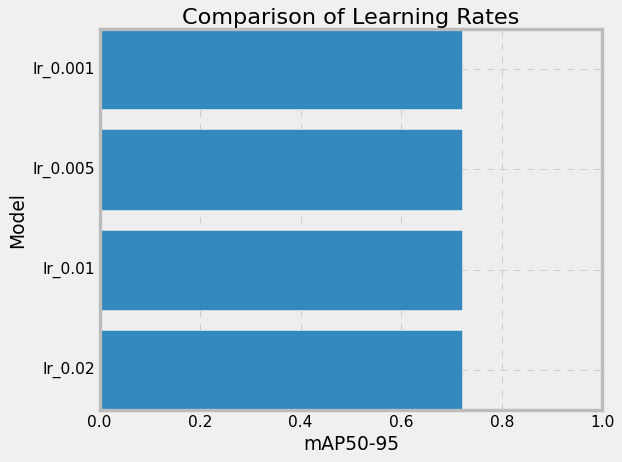

In [39]:
%matplotlib inline

plt.style.use('bmh')
plt.clf()

fig, ax = plt.subplots()

ax.barh(df_lr['model'], df_lr['metrics/mAP50-95(B)'])

ax.set_xlabel('mAP50-95')
ax.set_xlim(0, 1.0)
ax.set_ylabel('Model')
ax.set_title('Comparison of Learning Rates')
plt.tight_layout()
plt.show();

In [3]:
from ultralytics import YOLO

model_list = [('yolo11n.pt', 'nano'), ('yolo11s.pt', 'small')]

for model_path, size in model_list:
    model = YOLO(model_path)

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                imgsz=640,
                batch=8,
                lr0=0.01,
                device=0,
                name=f'{dataset_name}_{size}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.3.250 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-obj

In [4]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

model_size = ['nano', 'small']

for run in model_size:
    result_path = os.path.join(run_dir, f'{dataset_name}_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
54,nano,0.72132,0.97434,0.96130
89,small,0.70617,0.97435,0.96176


In [5]:
from ultralytics import YOLO

img_size = [512, 640, 768]

for size in img_size:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                imgsz=size,
                batch=8,
                lr0=0.01,
                device=0,
                name=f'{dataset_name}_imgsz_{size}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.3.250 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-obj

In [6]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

img_size = [512, 640, 768]

for run in img_size:
    result_path = os.path.join(run_dir, f'{dataset_name}_imgsz_{size}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'imgsz_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
49,imgsz_512,0.71904,0.95027,0.96765
49,imgsz_640,0.71904,0.95027,0.96765
49,imgsz_768,0.71904,0.95027,0.96765
